### ***Task 1: Smart Product Recommendation Engine***
---

In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv",
    on_bad_lines='skip'
)
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
print(df.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


In [4]:
df['articleType'].value_counts().head(30)

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Name: count, dtype: int64

In [5]:
complementary_maps = {
    "Sports Shoes": ["Socks", "Shorts", "Backpacks"],
    "Casual Shoes": ["Jeans", "Tshirts", "Belts"],
    "Formal Shoes": ["Trousers", "Shirts", "Belts"],
    "Tshirts": ["Jeans", "Shorts", "Casual Shoes"],
    "Shirts": ["Trousers", "Belts", "Formal Shoes"],
    "Dresses": ["Heels", "Handbags", "Earrings"],
    "Kurtas": ["Flats", "Handbags", "Earrings"],
    "Tops": ["Jeans", "Flats", "Handbags"],
    "Jeans": ["Tshirts", "Casual Shoes", "Belts"],
    "Watches": ["Shirts", "Tshirts", "Formal Shoes"]
}

In [6]:
def recommend_products(article_type): 

    return complementary_maps.get(
        article_type,
        ["No recommendations available"]
    )

recommend_products("Sports Shoes")

['Socks', 'Shorts', 'Backpacks']

In [7]:
def get_products(category, n=3):

    products = df[

    df['articleType'] == category
    ]

    return products.sample(
        min(n, len(products))
    )[["id", "productDisplayName"]]

get_products('Socks')

,id,productDisplayName
10867,51143,Parx Men White Socks
23483,58315,Jockey LCESCBRA Men White Pack of 3 Socks 2004
34898,40017,ADIDAS Unisex White Adicrew Socks


In [8]:

def recommend_complementary_products(article_type):

    recommendations = {}

    categories = recommend_products(article_type)

    for category in categories:

        recommendations[category] = get_products(category)
        
    return recommendations
    
recommend_complementary_products(
    "Sports Shoes"
)

{'Socks':           id                  productDisplayName
 41238  49288           Arrow Men Pack of 5 Socks
 36672  15278         Nike Men Sports White Socks
 13682  12404  Reid & Taylor Men Solid Grey Socks,
 'Shorts':           id            productDisplayName
 10093  32420       ADIDAS Men Black Shorts
 2581   34250  Proline Charcoal Grey Shorts
 29586  28544          Nike Men Grey Shorts,
 'Backpacks':           id                                productDisplayName
 39080  17293                              Nike Unisex Backpack
 13186   8217  Fastrack Unisex Blue Green Single Strap Backpack
 30025   9911     Puma Women Fitness Large Hobo Black Backpacks}

In [9]:
import os 
image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"
print(os.listdir(image_dir)[:5])



['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg']


In [10]:
import matplotlib.pyplot as plt
from PIL import Image 

def visualize_recommendations(recommendations):

    for category, products in recommendations.items():
        print(f"\n{category}")
        
        plt.figure(figsize=(12,4))

        for i, (_, row) in enumerate(products.iterrows()):

            image_path = (
                f"{image_dir}/{row['id']}.jpg"
            )

            try:
                img = Image.open(image_path)
                plt.subplot(
                    1, 
                    len(products),
                    i+1
                )
                plt.imshow(img)
                plt.axis("off")
                plt.title(
                    row["productDisplayName"][:20],
                    fontsize=8
                )
            except:
                pass
        
        plt.show()


Shirts


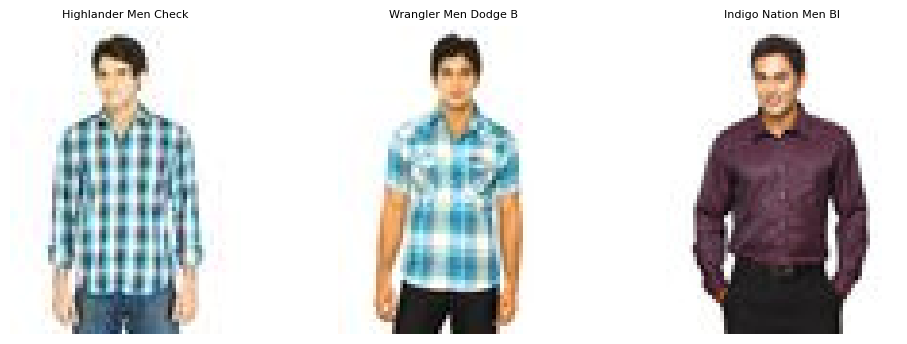


Tshirts


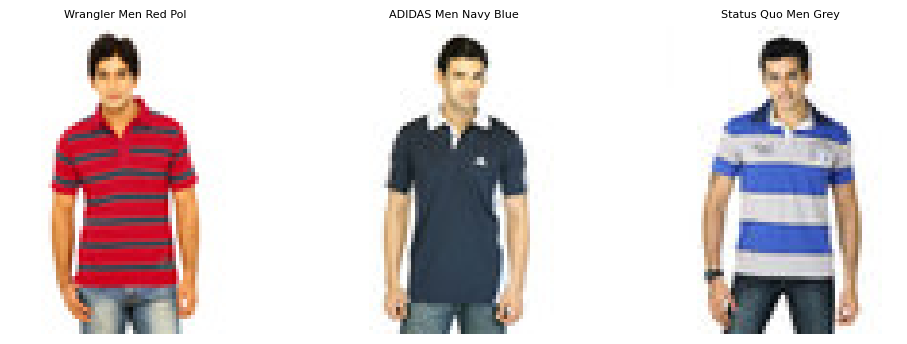


Formal Shoes


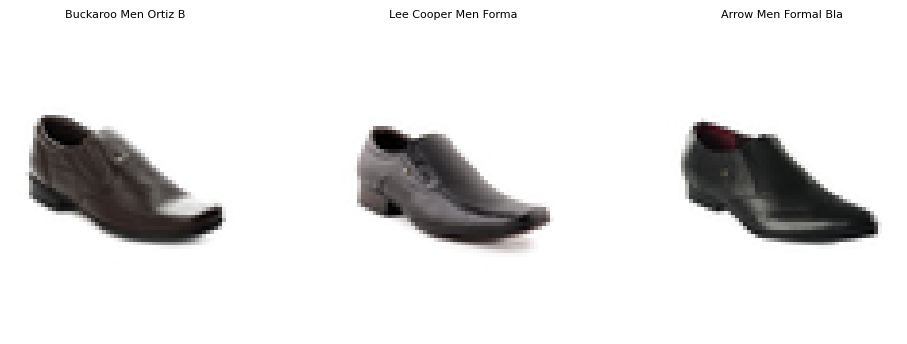

In [11]:
#final o/p:
visualize_recommendations(
    recommend_complementary_products("Watches")
)

### ***Task 2: Unique Product Catalog Creation***
---

In [2]:
import os

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

all_images = [
    os.path.join(image_dir, img)
    for img in os.listdir(image_dir)
][:500]

print(len(all_images))

500


In [1]:
from transformers import AutoImageProcessor, AutoModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

model = AutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k"
).to(device)

cuda


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [3]:
from PIL import Image 
import numpy as np

def get_embedding(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = model(**inputs)
        emb = outputs.pooler_output 

    emb = emb.cpu().numpy()
    emb = emb / np.linalg.norm(
        emb,
        axis=1,
        keepdims=True
    )

    return emb[0]
    

In [4]:
from tqdm import tqdm

embeddings = []

for image_path in tqdm(all_images):

    embeddings.append(
        get_embedding(image_path)
    )

embeddings = np.array(embeddings)

100%|██████████| 500/500 [00:10<00:00, 46.70it/s]


In [5]:
print(embeddings.shape)

(500, 768)


In [7]:
from sklearn.metrics.pairwise import cosine_similarity 

similarity_matrix = cosine_similarity(
    embeddings
)
similarity_matrix

array([[0.9999999 , 0.3773801 , 0.48343354, ..., 0.48959383, 0.5091313 ,
        0.45830846],
       [0.3773801 , 1.0000002 , 0.467219  , ..., 0.5787778 , 0.6360637 ,
        0.41904986],
       [0.48343354, 0.467219  , 1.0000002 , ..., 0.6159197 , 0.60447884,
        0.42539367],
       ...,
       [0.48959383, 0.5787778 , 0.6159197 , ..., 0.99999964, 0.7731161 ,
        0.40273097],
       [0.5091313 , 0.6360637 , 0.60447884, ..., 0.7731161 , 1.0000004 ,
        0.41962245],
       [0.45830846, 0.41904986, 0.42539367, ..., 0.40273097, 0.41962245,
        0.99999964]], shape=(500, 500), dtype=float32)

In [8]:
similarity_matrix[0][1]

np.float32(0.3773801)

In [10]:
threshold = 0.90

visited = set()
groups = []

for i in range(len(all_images)):

    if i in visited:
        continue

    current_group = [i]
    visited.add(i)

    for j in range(i + 1, len(all_images)):
        if similarity_matrix[i][j] > threshold:

            current_group.append(j)
            visited.add(j)

    groups.append(current_group)



In [17]:
groups[:50]

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13, 318],
 [14],
 [15],
 [16],
 [17],
 [18, 153, 192],
 [19],
 [20],
 [21, 148],
 [22],
 [23],
 [24],
 [25],
 [26],
 [27],
 [28],
 [29],
 [30],
 [31],
 [32, 203, 402, 484],
 [33],
 [34],
 [35],
 [36, 122],
 [37],
 [38],
 [39],
 [40, 112, 266],
 [41],
 [42],
 [43, 349, 432],
 [44],
 [45],
 [46, 171],
 [47],
 [48, 140, 473],
 [49]]

In [18]:
unique_catalog = [
    group[0]
    for group in groups 
]


In [20]:
print(len(all_images))
print(len(unique_catalog))

500
453


In [22]:
import matplotlib.pyplot as plt

def show_group(group):

    plt.figure(
        figsize=(15,3)
    )

    for i, idx in enumerate(group):

        img = Image.open(
            all_images[idx]
        )

        plt.subplot(
            1,
            len(group),
            i+1
        )

        plt.imshow(img)

        plt.axis("off")

    plt.show()

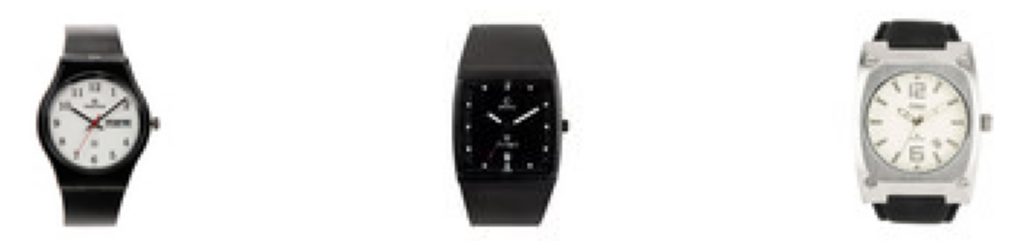

In [27]:
show_group(groups[18])

In [28]:
import pandas as pd

catalog = pd.DataFrame({
    "index": unique_catalog,
    "image_path": [
        all_images[idx]
        for idx in unique_catalog 
    ]
})

In [29]:
catalog

,index,image_path
0,0,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,1,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,2,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,3,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,4,/kaggle/input/datasets/paramaggarwal/fashion-p...
...,...,...
448,494,/kaggle/input/datasets/paramaggarwal/fashion-p...
449,495,/kaggle/input/datasets/paramaggarwal/fashion-p...
450,496,/kaggle/input/datasets/paramaggarwal/fashion-p...
451,498,/kaggle/input/datasets/paramaggarwal/fashion-p...


### ***Task 3: Reverse Product Search***
----

In [123]:
import os

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

all_image_names = os.listdir(image_dir)[:2000]

all_image_paths = [
    os.path.join(image_dir, img)
    for img in all_image_names
]

print(len(all_image_paths))

2000


In [67]:
!pip install -q transformers sentencepiece

In [68]:
from transformers import CLIPProcessor
from transformers import CLIPModel

import torch

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
import numpy as np

In [124]:
def get_image_embedding(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = clip_model.get_image_features(
            **inputs
        )

        embedding = outputs.pooler_output

    embedding = embedding.cpu().numpy()

    embedding = embedding / np.linalg.norm(
        embedding,
        axis=1,
        keepdims=True
    )

    return embedding

In [125]:
emb = get_image_embedding(
    all_image_paths[0]
)

print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(1, 512)


In [126]:
from tqdm import tqdm

image_embeddings = []

for image_path in tqdm(all_image_paths):

    emb = get_image_embedding(
        image_path
    )

    image_embeddings.append(
        emb[0]
    )

image_embeddings = np.array(
    image_embeddings
)

print(image_embeddings.shape)

100%|██████████| 2000/2000 [00:34<00:00, 58.15it/s]

(2000, 512)


In [127]:
import faiss

dimension = image_embeddings.shape[1]

index = faiss.IndexFlatIP(
    dimension
)

index.add(
    image_embeddings.astype(
        "float32"
    )
)

print(index.ntotal)
print(index.d)

2000
512


In [128]:
def get_text_embedding(text):

    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():

        outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        embedding = outputs.pooler_output

    embedding = embedding.cpu().numpy()

    embedding = embedding / np.linalg.norm(
        embedding,
        axis=1,
        keepdims=True
    )

    return embedding

In [129]:
text_emb = get_text_embedding(
    "blue casual shirt"
)

print(text_emb.shape)

(1, 512)


In [130]:
def reverse_product_search(
    query,
    k=5
):

    query_embedding = get_text_embedding(
        query
    )

    scores, indices = index.search(
        query_embedding.astype(
            "float32"
        ),
        k
    )

    return indices[0], scores[0]

In [131]:
indices, scores = reverse_product_search(
    "blue casual shirt",
    k=5
)

print(indices)
print(scores)

[1961 1754 1620  262 1424]
[0.07671387 0.07523975 0.07214722 0.0695463  0.06811687]


In [120]:
import matplotlib.pyplot as plt
from PIL import Image

In [132]:
def show_results(query, k=5):

    indices, scores = reverse_product_search(
        query,
        k
    )

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(indices):

        img = Image.open(
            all_image_paths[idx]
        )

        plt.subplot(
            1,
            k,
            i+1
        )

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"{scores[i]:.2f}"
        )

    plt.suptitle(query)

    plt.show()
    

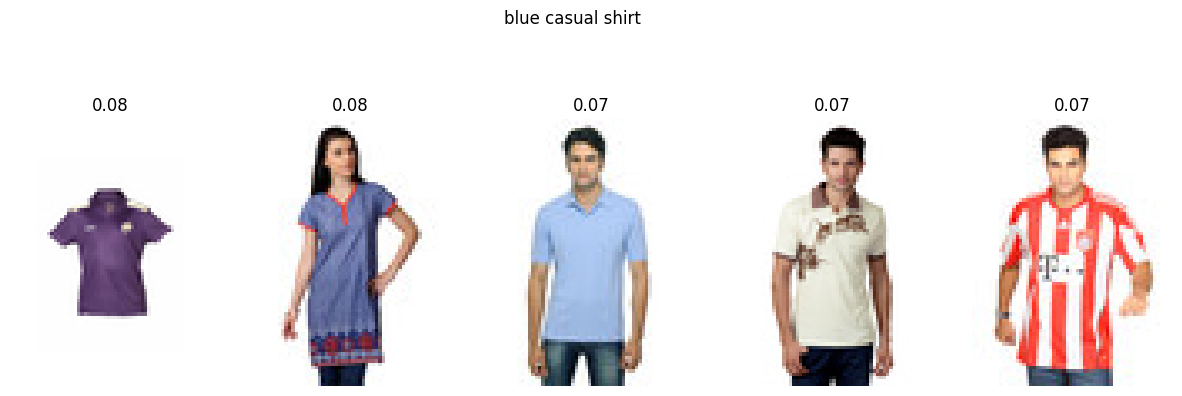

In [135]:
show_results("blue casual shirt")

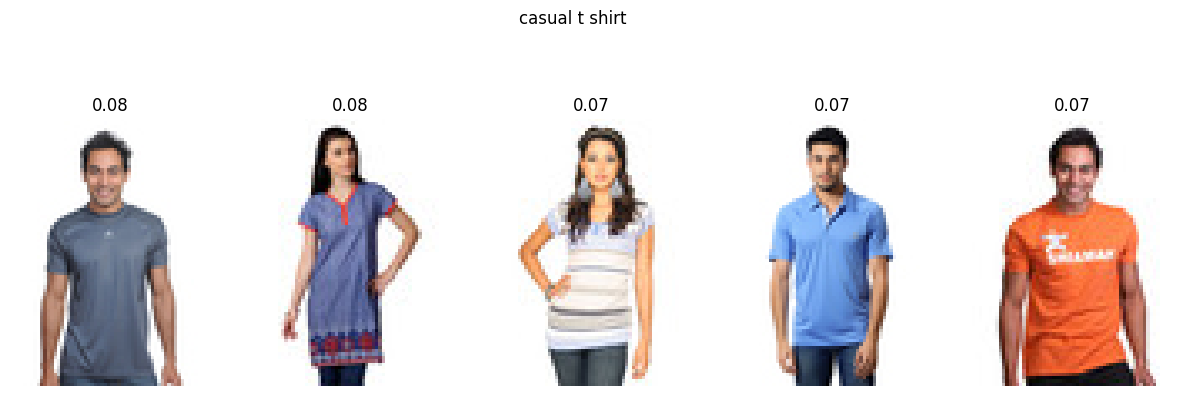

In [136]:
show_results("casual t shirt")